# Google Flights Airfare Forecast


Here’s a data science project inspired by a real-world problem. Use this opportunity to sharpen your skills and build a portfolio piece that will enhance your resume.

👉 To upskill in data science: [datascienceschool.com](https://datascienceschool.com) <br>
👉 To ace interviews in data/ML: [datainterview.com](https://datainterview.com)

------

Usage Terms:
This project is intended for personal and educational purposes only. For any other use, including commercial purposes or redistribution, please contact the author for written consent.

In [50]:
#@title Setup
from datetime import datetime, timedelta
from warnings import filterwarnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.feature_selection import (RFE, SelectKBest, f_regression)
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import train_test_split


# Ignore warnings
filterwarnings('ignore')

# Set seed
SEED = 123
np.random.seed(SEED)

# 🎯 Step 1 - Problem Definition

Build a data science solution that addresses the following:

1. Predict Airline Price: Build a model that forecasts the price of a flight based on its booking date. You will be provided a historical booking data that includes departure date, booking date, airline, destination and such.

2. Scenario Planning for Savings: Once your model can predict the price, we want to create a “what-if” feature. This feature will help users see how much they might save or spend by booking on different dates. For example, if a user books a flight from San Francisco to New York on December 15, they could explore alternative booking dates to see if booking on a different date would yield a better price.

In [2]:
# Load data
df_booking = pd.read_csv("google_flights_airfare_data.csv")
df_booking.head()

,transaction_id,flight_id,airline,origin,destination,booking_dt,departure_dt,price,fare_class
0,898b2db0d,ced9a2,American Airlines,ORD,BOS,2024-04-02 14:00:10,2024-07-09 07:47:00,327.15,Economy
1,5b8144206,ced9a2,American Airlines,ORD,BOS,2024-05-19 08:44:17,2024-07-09 07:47:00,191.25,Economy
2,2e458f769,ced9a2,American Airlines,ORD,BOS,2024-02-23 22:11:51,2024-07-09 07:47:00,579.79,Economy
3,2c9e3e129,ced9a2,American Airlines,ORD,BOS,2024-04-22 23:43:37,2024-07-09 07:47:00,579.06,Economy
4,9de7ad563,ced9a2,American Airlines,ORD,BOS,2024-04-28 17:55:53,2024-07-09 07:47:00,207.06,Economy


# 🗺️ Step 2 - Exploratory Data Analysis

✍️ The Exploratory Data Analysis (EDA) section delves into the provided airfare dataset to understand its characteristics, identify patterns, and uncover insights that inform model development. Here's a guideline you can consider when approaching section:

1. Generate tables and/or charts that illustrate insights.
2. Identify potential data quality issues that require addressing.
3. Discover patterns and trends that can guide feature engineering and model selection.

## Overview

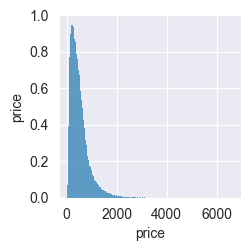

In [3]:
df_booking.head()# YOUR CODE BELOW
sns.pairplot(df_booking)
#plt.tight_layout()
plt.show()

In [28]:
df_booking.dtypes

transaction_id                     str
flight_id                          str
airline                            str
origin                             str
destination                        str
booking_dt              datetime64[us]
departure_dt            datetime64[us]
price                          float64
fare_class                         str
days_until_departure             int64
booking_month                    int32
booking_dow                      int32
departure_month                  int32
departure_dow                    int32
dtype: object

In [27]:
# Convert date columns from string to datetime
df_booking['booking_dt'] = pd.to_datetime(df_booking['booking_dt'])
df_booking['departure_dt'] = pd.to_datetime(df_booking['departure_dt'])




## Missingness

In [21]:
# YOUR CODE BELOW
df_booking.isnull().sum()

transaction_id          0
flight_id               0
airline                 0
origin                  0
destination             0
booking_dt              0
departure_dt            0
price                   0
fare_class              0
days_until_departure    0
booking_month           0
booking_dow             0
departure_month         0
departure_dow           0
dtype: int64

In [10]:
# Feature engineering
df_booking['days_until_departure'] = (df_booking['departure_dt'] - df_booking['booking_dt']).dt.days
df_booking['booking_month'] = df_booking['booking_dt'].dt.month
df_booking['booking_dow'] = df_booking['booking_dt'].dt.dayofweek
df_booking['departure_month'] = df_booking['departure_dt'].dt.month
df_booking['departure_dow'] = df_booking['departure_dt'].dt.dayofweek





In [23]:
df_booking.head()



,transaction_id,flight_id,airline,origin,destination,booking_dt,departure_dt,price,fare_class,days_until_departure,booking_month,booking_dow,departure_month,departure_dow
0,898b2db0d,ced9a2,American Airlines,ORD,BOS,2024-04-02 14:00:10,2024-07-09 07:47:00,327.15,Economy,97,4,1,7,1
1,5b8144206,ced9a2,American Airlines,ORD,BOS,2024-05-19 08:44:17,2024-07-09 07:47:00,191.25,Economy,50,5,6,7,1
2,2e458f769,ced9a2,American Airlines,ORD,BOS,2024-02-23 22:11:51,2024-07-09 07:47:00,579.79,Economy,136,2,4,7,1
3,2c9e3e129,ced9a2,American Airlines,ORD,BOS,2024-04-22 23:43:37,2024-07-09 07:47:00,579.06,Economy,77,4,0,7,1
4,9de7ad563,ced9a2,American Airlines,ORD,BOS,2024-04-28 17:55:53,2024-07-09 07:47:00,207.06,Economy,71,4,6,7,1


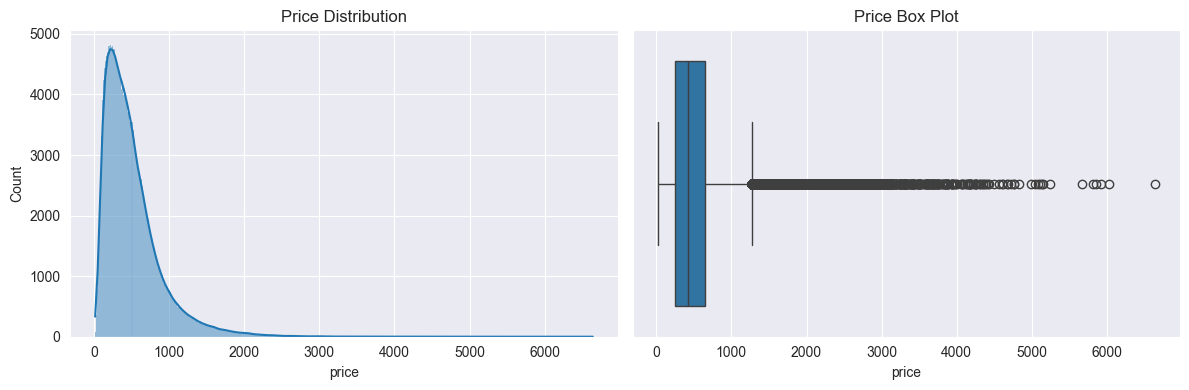

In [12]:
# YOUR CODE BELOW# 1. Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_booking['price'], kde=True, ax=axes[0])
axes[0].set_title('Price Distribution')
sns.boxplot(x=df_booking['price'], ax=axes[1])
axes[1].set_title('Price Box Plot')
plt.tight_layout()
plt.show()

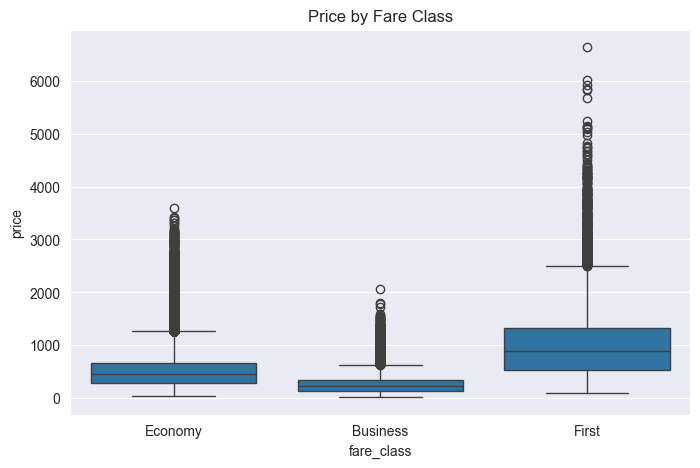

In [13]:
# 2. Price by Fare Class
plt.figure(figsize=(8, 5))
sns.boxplot(x='fare_class', y='price', data=df_booking)
plt.title('Price by Fare Class')
plt.show()


## Univariate Analysis

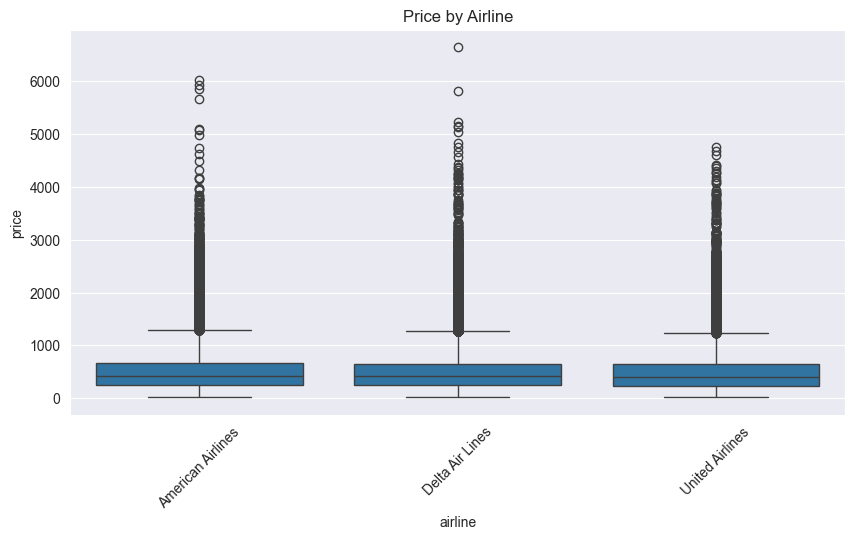

In [14]:
# YOUR CODE BELOW
# 3. Price by Airline
plt.figure(figsize=(10, 5))
sns.boxplot(x='airline', y='price', data=df_booking)
plt.xticks(rotation=45)
plt.title('Price by Airline')
plt.show()

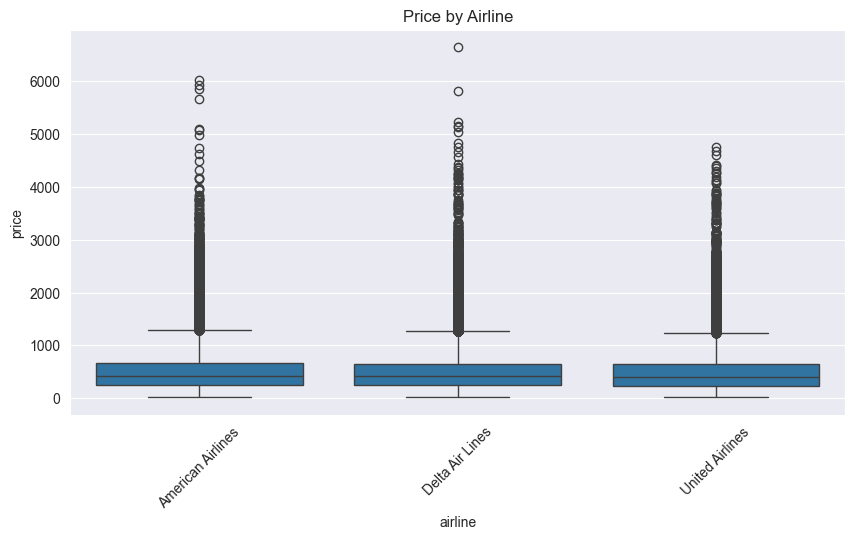

In [14]:
# YOUR CODE BELOW
# 3. Price by Airline
plt.figure(figsize=(10, 5))
sns.boxplot(x='airline', y='price', data=df_booking)
plt.xticks(rotation=45)
plt.title('Price by Airline')
plt.show()

## Target Analysis

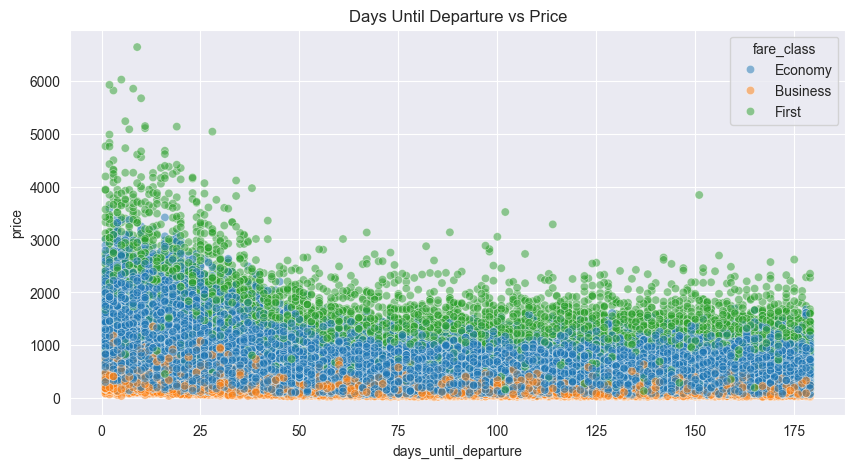

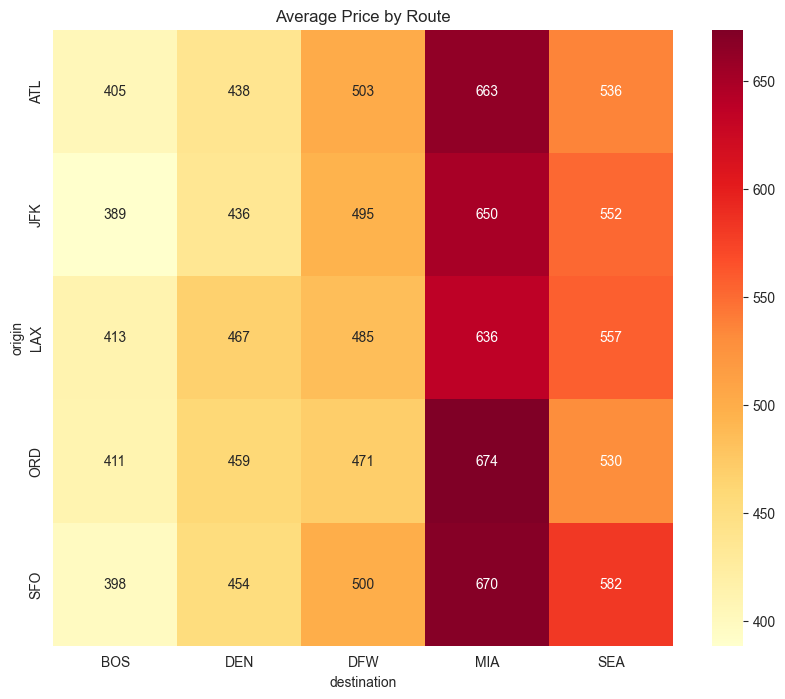

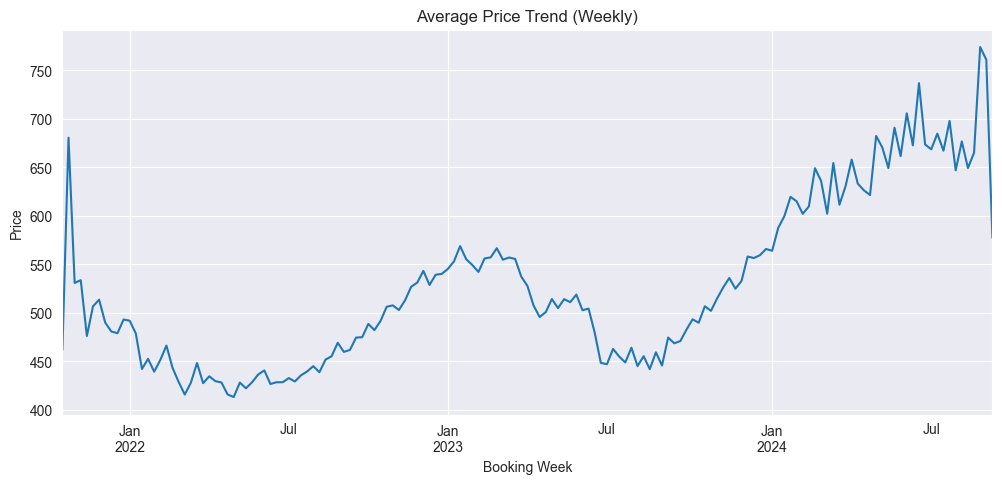

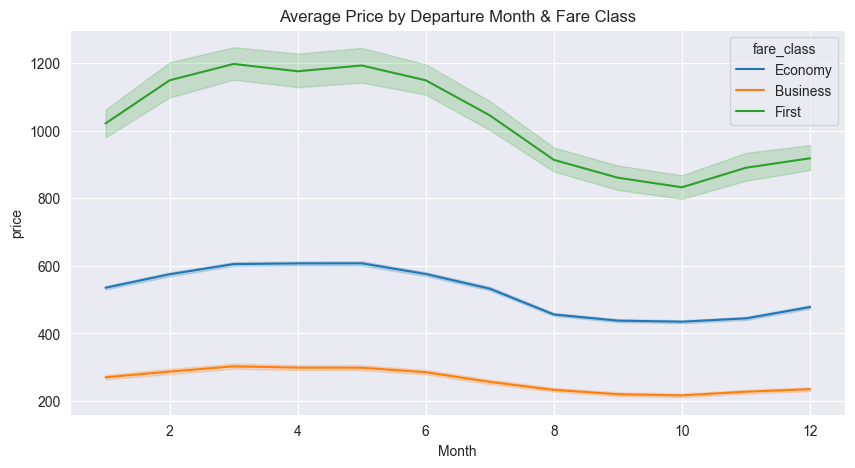

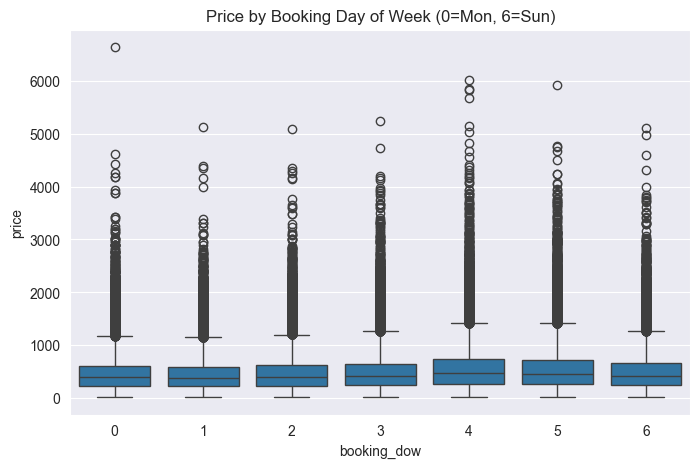

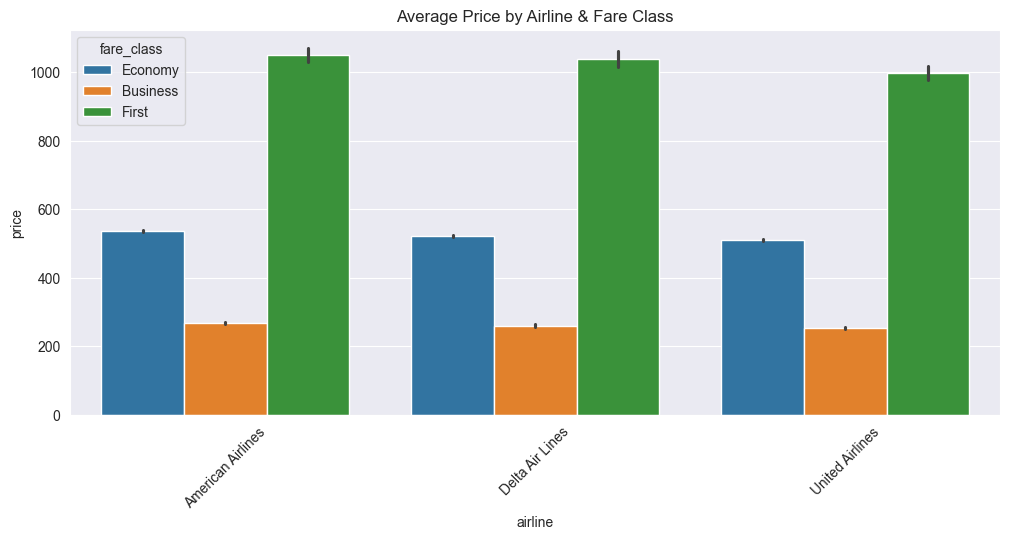

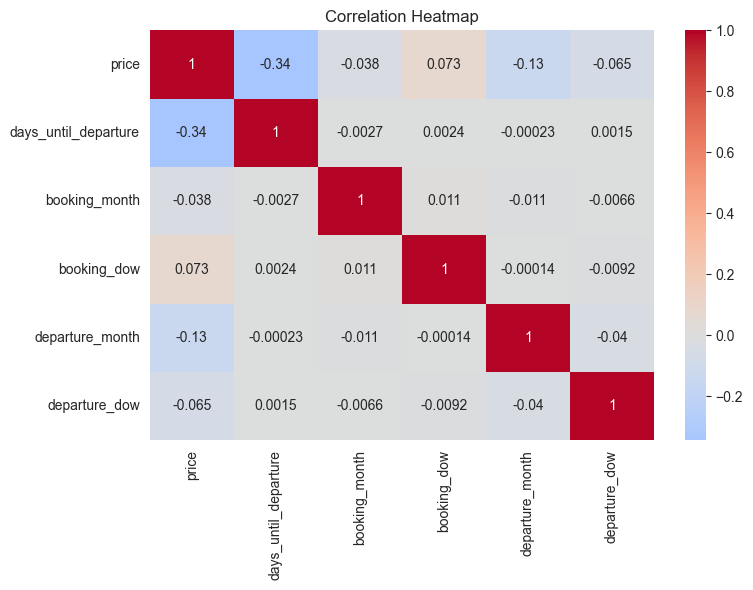

In [16]:
# YOUR CODE BELOW
# 4. Days Until Departure vs Price
plt.figure(figsize=(10, 5))
sns.scatterplot(x='days_until_departure', y='price', hue='fare_class', data=df_booking, alpha=0.5)
plt.title('Days Until Departure vs Price')
plt.show()

# 5. Average Price by Route (Heatmap)
plt.figure(figsize=(10, 8))
pivot = df_booking.pivot_table(values='price', index='origin', columns='destination', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Average Price by Route')
plt.show()

# 6. Price Trend Over Time (Weekly)
plt.figure(figsize=(12, 5))
df_booking.groupby(df_booking['booking_dt'].dt.to_period('W'))['price'].mean().plot()
plt.title('Average Price Trend (Weekly)')
plt.ylabel('Price')
plt.xlabel('Booking Week')
plt.show()

# 7. Monthly Seasonality by Fare Class
plt.figure(figsize=(10, 5))
sns.lineplot(x='departure_month', y='price', hue='fare_class', data=df_booking)
plt.title('Average Price by Departure Month & Fare Class')
plt.xlabel('Month')
plt.show()

# 8. Price by Day of Week (Booking)
plt.figure(figsize=(8, 5))
sns.boxplot(x='booking_dow', y='price', data=df_booking)
plt.title('Price by Booking Day of Week (0=Mon, 6=Sun)')
plt.show()

# 9. Average Price by Airline & Fare Class
plt.figure(figsize=(12, 5))
sns.barplot(x='airline', y='price', hue='fare_class', data=df_booking, estimator='mean')
plt.xticks(rotation=45)
plt.title('Average Price by Airline & Fare Class')
plt.show()

# 10. Correlation Heatmap (numeric features)
plt.figure(figsize=(8, 6))
numeric_cols = ['price', 'days_until_departure', 'booking_month', 'booking_dow', 'departure_month', 'departure_dow']
sns.heatmap(df_booking[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

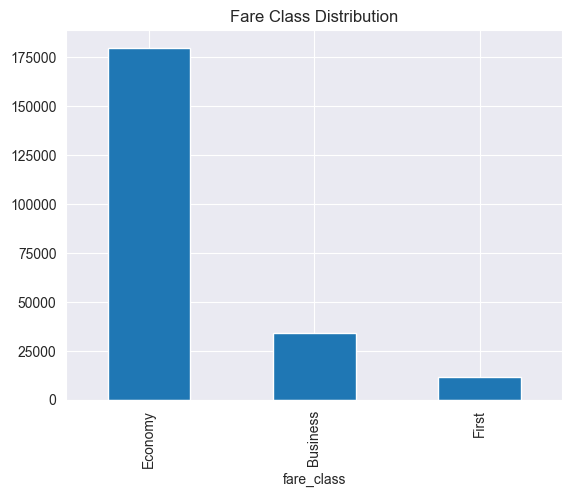

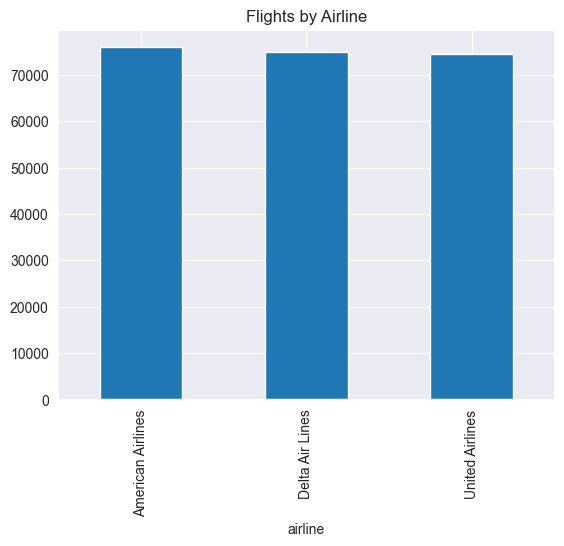

In [26]:
# Univariate - numeric
df_booking['price'].describe()

# Univariate - categorical
df_booking['fare_class'].value_counts().plot(kind='bar', title='Fare Class Distribution')
plt.show()

df_booking['airline'].value_counts().plot(kind='bar', title='Flights by Airline')
plt.show()


# 🛢️ Step 3 - Data Preparation

✍️ Data preparation transforms raw data into a suitable format for machine learning models, enhancing their accuracy and efficiency. Your task is to clean, transform, and organize the airfare data. Here are suggestions:

*   Format Fields: Ensure data types are appropriate for analysis (e.g., datetime, categorical).
*   Split Data: Divide the dataset into training, validation, and testing sets to evaluate model performance robustly. Consider chronological order for time-series data.

💡 You are not restricted to these steps. If you identify additional steps to enhance the data, feel free to include them!

## Format Fields

In [55]:
# YOUR CODE BELOW
df_booking['booking_dt'] = pd.to_datetime(df_booking['booking_dt'])
df_booking['departure_dt'] = pd.to_datetime(df_booking['departure_dt'])

#One-Hot Encoding (better for linear models)
#df_encoded = pd.get_dummies(df_booking, columns=['airline', 'origin', 'destination', 'fare_class'], drop_first=True)
#Label coding instead to be used so that the model trains on all fields instead of dropping with one hot encoding.
df_encoded = df_booking.copy()

le_airline = LabelEncoder()
le_origin = LabelEncoder()
le_destination = LabelEncoder()
le_fare_class = LabelEncoder()

df_encoded['airline'] = le_airline.fit_transform(df_encoded['airline'])
df_encoded['origin'] = le_origin.fit_transform(df_encoded['origin'])
df_encoded['destination'] = le_destination.fit_transform(df_encoded['destination'])
df_encoded['fare_class'] = le_fare_class.fit_transform(df_encoded['fare_class'])



In [57]:
df_encoded.nunique()


transaction_id          225208
flight_id                 2189
airline                      3
origin                       5
destination                  5
booking_dt              224815
departure_dt              2186
price                    96069
fare_class                   3
days_until_departure       179
booking_month               12
booking_dow                  7
departure_month             12
departure_dow                7
dtype: int64

## Split Data

In [58]:
# YOUR CODE BELOW
X = df_encoded.drop(columns=['price', 'transaction_id', 'flight_id', 'booking_dt', 'departure_dt'])
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")



Train size: 180167
Test size: 45042


# 🚀 Step 4 - Feature Engineering

✍️ Feature engineering boosts model performance! It's about creating new features from existing ones to help the model better understand the data and improve predictions.

Here are suggestions to help you create new features:

1. **Compute Delta**: Calculate the time difference between booking and departure dates, as it's likely a key factor in pricing.
2. **Decompose Timestamps**: Extract valuable information from booking and departure dates, like year, month, day of the week, etc.

💡 If you think of any other features that could be insightful, go ahead and experiment. Feature engineering is all about finding what works best for your model!

## Compute Delta

In [59]:
# YOUR CODE BELOW --- I featured the fields below the split
df_encoded['days_until_departure']

0          97
1          50
2         136
3          77
4          71
         ... 
225204    165
225205    102
225206     48
225207    151
225208    176
Name: days_until_departure, Length: 225209, dtype: int64

## Decompose TS

In [60]:
# YOUR CODE BELOW --decompeosd before the split
df_encoded[['booking_month', 'booking_dow']]

,booking_month,booking_dow
0,4,1
1,5,6
2,2,4
3,4,0
4,4,6
...,...,...
225204,3,1
225205,5,1
225206,7,6
225207,4,1


# 📍 Step 5 - Feature Selection

✍️ Feature selection prevents model overfitting and improves training speed. Find the most relevant features for model prediction. You can consider a method such as the Random Forest Feature Importance.

## RF Feature Selection

In [71]:
# YOUR CODE BELOW
rfe = RFE(estimator=xgb.XGBRegressor(random_state=SEED), n_features_to_select=10)
rfe.fit(X_train, y_train)
selected_features = X_train.columns[rfe.support_]
print("Selected features:", selected_features.tolist())



Selected features: ['airline', 'origin', 'destination', 'fare_class', 'days_until_departure', 'booking_month', 'booking_dow', 'departure_month', 'departure_dow']


## Feature Importance

In [72]:
# YOUR CODE BELOW
print("Selected features:", selected_features.tolist())


Selected features: ['airline', 'origin', 'destination', 'fare_class', 'days_until_departure', 'booking_month', 'booking_dow', 'departure_month', 'departure_dow']


## Filter Columns

In [78]:
# YOUR CODE BELOW
y_train_log = np.log1p(y_train)

model_log = xgb.XGBRegressor(random_state=SEED, **best_params)
model_log.fit(X_train_selected, y_train_log)

y_test_pred = np.expm1(model_log.predict(X_test_selected))
print(f"Log-target Test MAPE: {mean_absolute_percentage_error(y_test, y_test_pred)*100:.2f}%")

Log-target Test MAPE: 52.60%


In [80]:
# Try all features + log target
model_all_log = xgb.XGBRegressor(random_state=SEED, **best_params)
model_all_log.fit(X_train, np.log1p(y_train))

y_pred_all_log = np.expm1(model_all_log.predict(X_test))
print(f"All features + log target Test MAPE: {mean_absolute_percentage_error(y_test, y_pred_all_log)*100:.2f}%")


All features + log target Test MAPE: 52.63%


In [79]:
# Add more features to df_encoded (before splitting)
df_encoded['route'] = LabelEncoder().fit_transform(
    df_booking['origin'] + '_' + df_booking['destination']
)
df_encoded['is_weekend_booking'] = df_encoded['booking_dow'].isin([5, 6]).astype(int)
df_encoded['is_weekend_departure'] = df_encoded['departure_dow'].isin([5, 6]).astype(int)
df_encoded['lead_time_bucket'] = pd.cut(
    df_encoded['days_until_departure'],
    bins=[-1, 3, 7, 21, 60, 999],
    labels=[0, 1, 2, 3, 4]
).astype(int)

# Re-split with new features
X = df_encoded.drop(columns=['price', 'transaction_id', 'flight_id', 'booking_dt', 'departure_dt'])
y = df_encoded['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# Train with log target
model_rich = xgb.XGBRegressor(random_state=SEED, **best_params)
model_rich.fit(X_train, np.log1p(y_train))

y_pred_rich = np.expm1(model_rich.predict(X_test))
print(f"Rich features + log target Test MAPE: {mean_absolute_percentage_error(y_test, y_pred_rich)*100:.2f}%")


Rich features + log target Test MAPE: 52.63%


# 🤖 Step 6 - Model Selection

✍️ Model selection is where we pick the champion algorithm that will power our predictions. It's about carefully evaluating different models and choosing the one that best suits our dataset and prediction task.

Your task is to experiment with different model architectures, train them, and assess their performance.

Here are suggestions on how to start this process:

1. Baseline Model: Start by establishing a baseline performance benchmark with a simple yet effective model like XGBoost. This sets a foundation to compare against when exploring more complex approaches.

2. Hyperparameter Tuning: Fine-tune the parameters of your chosen model using techniques like grid search or random search to unlock its full potential and achieve optimal performance.

💡 Consider using the XGBoost model, or any other models (e.g., linear regression, random forest).

## Baseline Model

In [81]:
# YOUR CODE BELOW

# Filter to selected features only
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Baseline XGBoost model (default parameters)
baseline_model = xgb.XGBRegressor(random_state=SEED)
baseline_model.fit(X_train_selected, y_train)

# Predictions
y_train_pred = baseline_model.predict(X_train_selected)
y_test_pred = baseline_model.predict(X_test_selected)

# Evaluate using MAPE
train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred)

print(f"Train MAPE: {train_mape:.4f} ({train_mape*100:.2f}%)")
print(f"Test MAPE:  {test_mape:.4f} ({test_mape*100:.2f}%)")


Train MAPE: 0.5714 (57.14%)
Test MAPE:  0.5917 (59.17%)


## Hyperparameter Tuning

In [75]:
# YOUR CODE BELOW
from sklearn.model_selection import ParameterSampler

# Define parameter grid
param_grid = {
    'n_estimators': [100, 300, 500, 800, 1000],
    'max_depth': [4, 6, 8, 10, 12],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7]
}

# Randomly sample 30 combinations
random_params = list(ParameterSampler(param_grid, n_iter=30, random_state=SEED))

# Try each combination, track the best
best_mape = float('inf')
best_params = None
results = []

for i, params in enumerate(random_params):
    model = xgb.XGBRegressor(random_state=SEED, **params)
    model.fit(X_train_selected, y_train)

    y_train_pred = model.predict(X_train_selected)
    y_test_pred = model.predict(X_test_selected)

    train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
    test_mape = mean_absolute_percentage_error(y_test, y_test_pred)

    results.append({'params': params, 'train_mape': train_mape, 'test_mape': test_mape})

    if test_mape < best_mape:
        best_mape = test_mape
        best_params = params

    print(f"[{i+1}/30] Train MAPE: {train_mape*100:.2f}% | Test MAPE: {test_mape*100:.2f}%")

print(f"\n{'='*50}")
print(f"Best Test MAPE: {best_mape*100:.2f}%")
print(f"Best params: {best_params}")



[1/30] Train MAPE: 20.87% | Test MAPE: 67.60%
[2/30] Train MAPE: 54.71% | Test MAPE: 58.96%
[3/30] Train MAPE: 51.52% | Test MAPE: 59.70%
[4/30] Train MAPE: 57.19% | Test MAPE: 59.28%
[5/30] Train MAPE: 37.63% | Test MAPE: 63.29%
[6/30] Train MAPE: 32.85% | Test MAPE: 60.89%
[7/30] Train MAPE: 54.61% | Test MAPE: 59.10%
[8/30] Train MAPE: 58.02% | Test MAPE: 59.47%
[9/30] Train MAPE: 29.61% | Test MAPE: 63.80%
[10/30] Train MAPE: 58.11% | Test MAPE: 59.28%
[11/30] Train MAPE: 48.60% | Test MAPE: 59.64%
[12/30] Train MAPE: 40.37% | Test MAPE: 60.19%
[13/30] Train MAPE: 59.83% | Test MAPE: 60.51%
[14/30] Train MAPE: 57.85% | Test MAPE: 59.24%
[15/30] Train MAPE: 67.40% | Test MAPE: 69.15%
[16/30] Train MAPE: 77.55% | Test MAPE: 77.25%
[17/30] Train MAPE: 58.47% | Test MAPE: 59.41%
[18/30] Train MAPE: 57.42% | Test MAPE: 59.13%
[19/30] Train MAPE: 57.87% | Test MAPE: 59.34%
[20/30] Train MAPE: 49.42% | Test MAPE: 59.83%
[21/30] Train MAPE: 59.83% | Test MAPE: 60.51%
[22/30] Train MAPE: 49

count    225209.000000
mean        509.673779
std         385.889088
min          16.610000
25%         245.290000
50%         417.280000
75%         654.300000
max        6639.680000
Name: price, dtype: float64


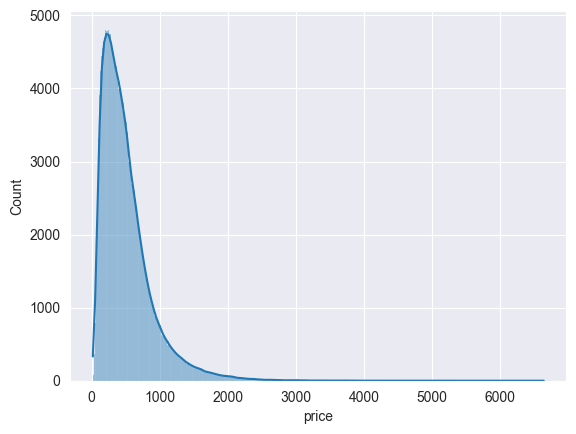

In [76]:
print(df_booking['price'].describe())
sns.histplot(df_booking['price'], kde=True)
plt.show()

In [77]:
q99 = df_encoded['price'].quantile(0.99)
print(f"99th percentile: ${q99:.2f}")
print(f"Rows above 99th: {(df_encoded['price'] > q99).sum()}")

99th percentile: $1919.55
Rows above 99th: 2253


# 📊 Step 7 - Evaluation

✍️ Model evaluation is where we put our model to the test and determine its true performance. It's about rigorously assessing how well our chosen model generalizes to unseen data and identifying any areas for improvement. Your task is to evaluate your model using a variety of metrics and techniques, focusing on:

Consider evaluating your model with the following points:

1. **Benchmark Comparison:** Compare your model's performance against a simple business method. This helps provide context and demonstrate the model's advantages over a simpler approach.

2. **Simpson's Paradox:** Note that model performance may vary when you assess the subgroups. Do you see that the ML approach is consistently better across subgroups such as airfare_class?

💡 Remember, model evaluation is more than just looking at a single metric. Consider using multiple metrics (e.g., MAPE, RMSE, R-squared) to get a comprehensive view of your model's performance.

## Evaluation Dataset

In [82]:
# YOUR CODE BELOW
#seprately test out each class with same model
# See how your current model performs per class
df_test = X_test.copy()
df_test['price_actual'] = y_test.values
df_test['price_pred'] = y_pred_rich  # or whatever your latest predictions are

for fc_val in df_test['fare_class'].unique():
    mask = df_test['fare_class'] == fc_val
    mape = mean_absolute_percentage_error(
        df_test.loc[mask, 'price_actual'],
        df_test.loc[mask, 'price_pred']
    )
    print(f"Fare class {fc_val}: MAPE = {mape*100:.2f}%")


Fare class 1: MAPE = 51.91%
Fare class 2: MAPE = 54.39%
Fare class 0: MAPE = 55.95%


## Business Method


In [16]:
# YOUR CODE BELOW

# ✈️ Step 8 - Airfare Scenario Planning

✍️ This is the main aim for the ML approach. We want to build a tool that uses ML to help useres make informed booking decisions.

Given the following inputs:

1. Current Date
2. Departure Date
3. Airline
4. Origin
5. Destination
6. Fare Class

Predict the future airfare prices across a range of potential booking dates. Present these predictions in a clear and understandable format. Consider using a chart.

💡 Consider providing an actionable insight that helps users identify the optimal booking date within a specified timeframe (e.g., next 7 days) to potentiallly maximize savings.

In [ ]:
# Choose flight

#@title Example Form
today_date = '2024-11-22' #@param {type:"string"}
departure_date = '2024-12-08' #@param {type:"string"}
airline = 'United Airlines' #@param ['American Airlines', 'Delta Air Lines', 'United Airlines']
origin = 'JFK' #@param ['JFK', 'LAX', 'ORD']
destination = 'LAX' #@param ['JFK', 'LAX', 'ORD']
fare_class = 'Business' #@param ["Economy", "Business", "First"]

# Check that the departure date is greater than the today date
if departure_date <= today_date:
    raise ValueError("Departure date must be greater than today's date.")

In [83]:
# YOUR CODE BELOW

In [84]:
X_test_with_pred = X_test.copy()
X_test_with_pred['actual_price'] = y_test.values
X_test_with_pred['predicted_price'] = np.expm1(model_log.predict(X_test_selected))

X_test_with_pred[['actual_price', 'predicted_price']].head(10)

,actual_price,predicted_price
44635,373.03,299.869598
200002,818.00,769.590576
196005,2110.76,1101.883545
126908,384.84,273.714569
152845,168.19,536.399475
37608,494.49,401.265106
156205,239.10,441.518433
72270,726.63,490.426727
160657,407.16,378.733002
153156,827.70,534.606934


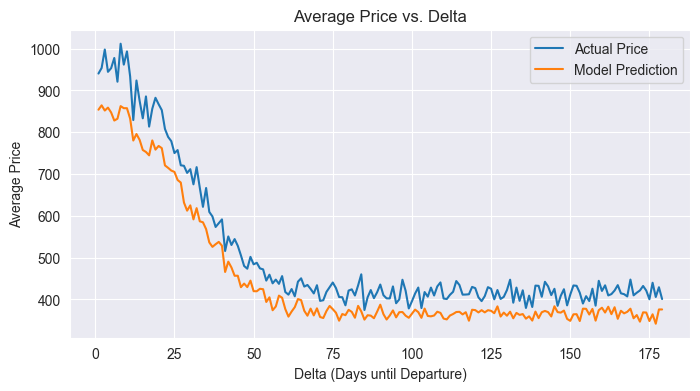

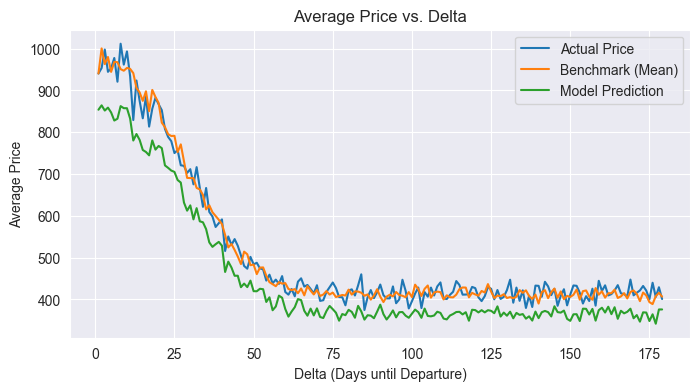

In [86]:
# Create evaluation dataframe
df_eval = X_test.copy()
df_eval['price'] = y_test.values
df_eval['predicted_price'] = np.expm1(model_log.predict(X_test_selected))
df_eval['delta'] = df_eval['days_until_departure']

# Average price vs days until departure
df_eval.groupby('delta')[['price', 'predicted_price']].mean().plot(figsize=(8, 4))
plt.xlabel('Delta (Days until Departure)')
plt.ylabel('Average Price')
plt.title('Average Price vs. Delta')
plt.legend(['Actual Price', 'Model Prediction'])
plt.show()

# Add benchmark: average price per delta from training data
benchmark = X_train.copy()
benchmark['price'] = y_train.values
benchmark_avg = benchmark.groupby('days_until_departure')['price'].mean()

df_eval['benchmark'] = df_eval['delta'].map(benchmark_avg)

# Plot all three
df_eval.groupby('delta')[['price', 'benchmark', 'predicted_price']].mean().plot(figsize=(8, 4))
plt.xlabel('Delta (Days until Departure)')
plt.ylabel('Average Price')
plt.title('Average Price vs. Delta')
plt.legend(['Actual Price', 'Benchmark (Mean)', 'Model Prediction'])
plt.show()
